### CNN - Computer Vision

##### Convolutional layer
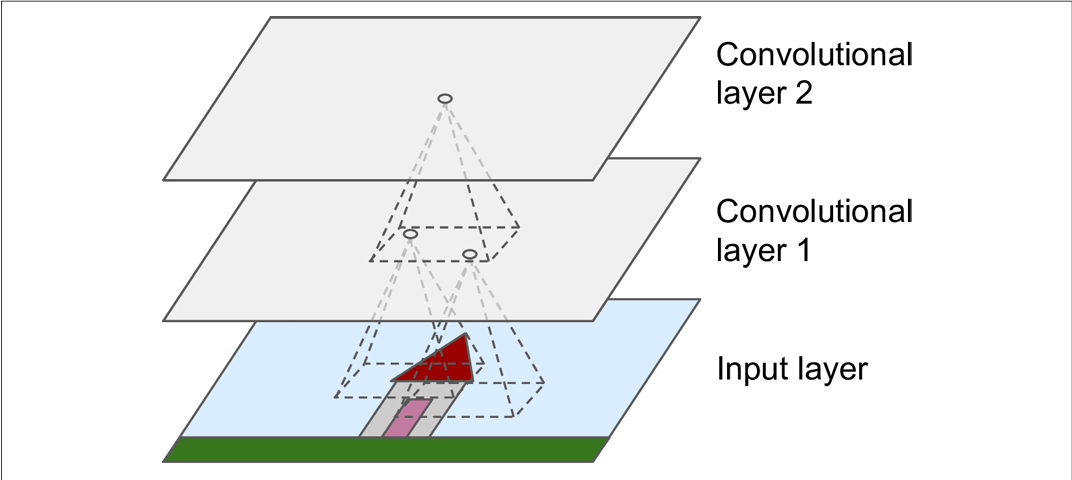


#### Filters

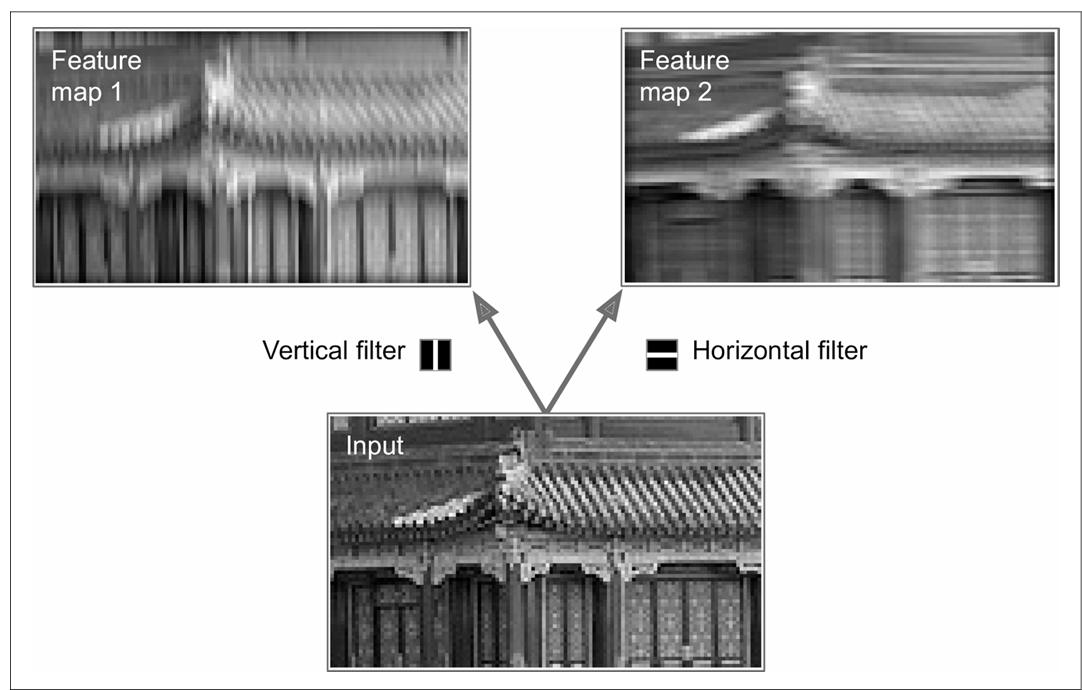

### Stacking Multiple Feature Maps
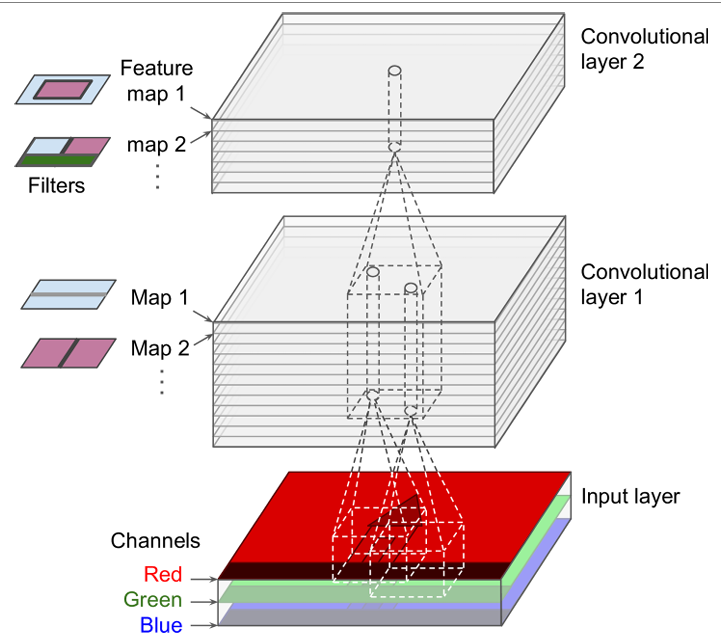

###  TensorFlow Implementation

In [1]:
from sklearn.datasets import load_sample_image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

KeyboardInterrupt: 

In [ ]:
china = load_sample_image("china.jpg")/255
flower = load_sample_image("flower.jpg")/255

In [ ]:
images = np.array([china ,flower])
batch_size ,weight ,height ,channels = images.shape

In [ ]:
# Create 2 filters: one for vertical edges and one for horizontal edges
filters = np.zeros(shape=(7,7,channels,2),dtype=np.float32)
filters[:,3 , :,0] = 1 # vertical edges
filters[3 , :, :,1] = 1 # horizontal edges

outputs = tf.nn.conv2d(images,filters,strides=1,padding="SAME")

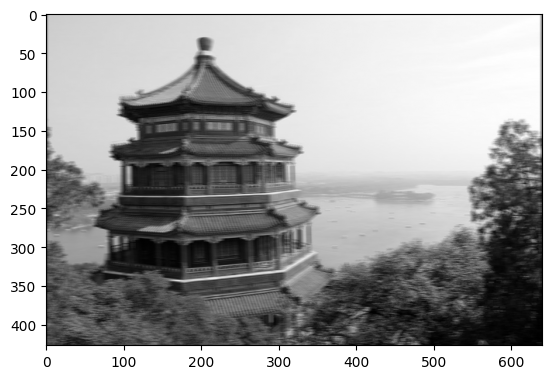

In [ ]:
#plot 1st images's 2nd feature map 
plt.imshow(outputs[0,:,:,1],cmap="gray")
plt.show()

#### Padding 
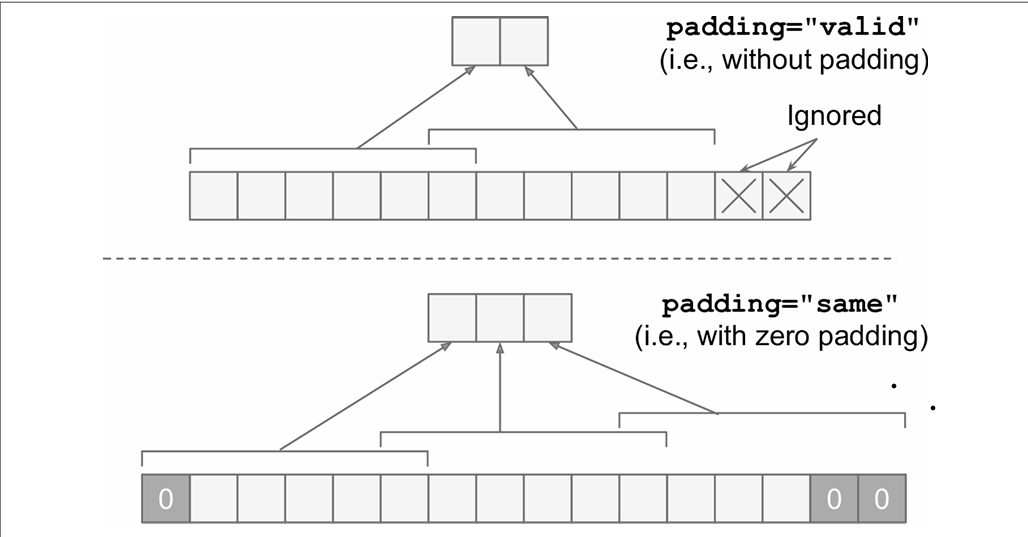

In [ ]:
#Instead of manually  creating the variables ,use the keras.layers.Conv2D 
import keras


conv  = keras.layers.Conv2D(filters=32,kernel_size=7,padding="same",activation="relu")

### Pooling Layers

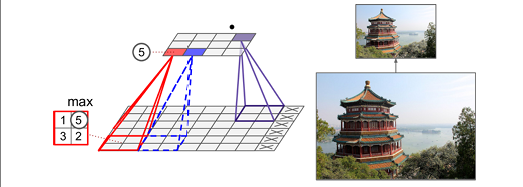

### Introduce some level of invariance

![Screenshot 2026-05-03 181730.png](<attachment:Screenshot 2026-05-03 181730.png>)
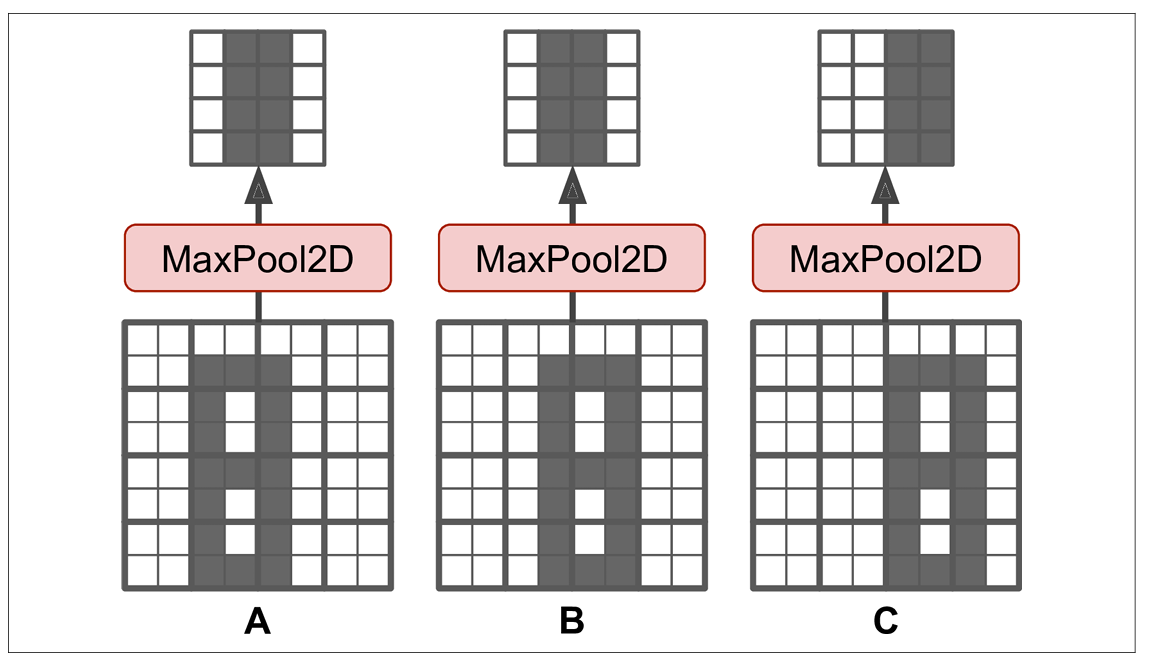

In [ ]:
max_pool = keras.layers.MaxPool1D(pool_size=2)

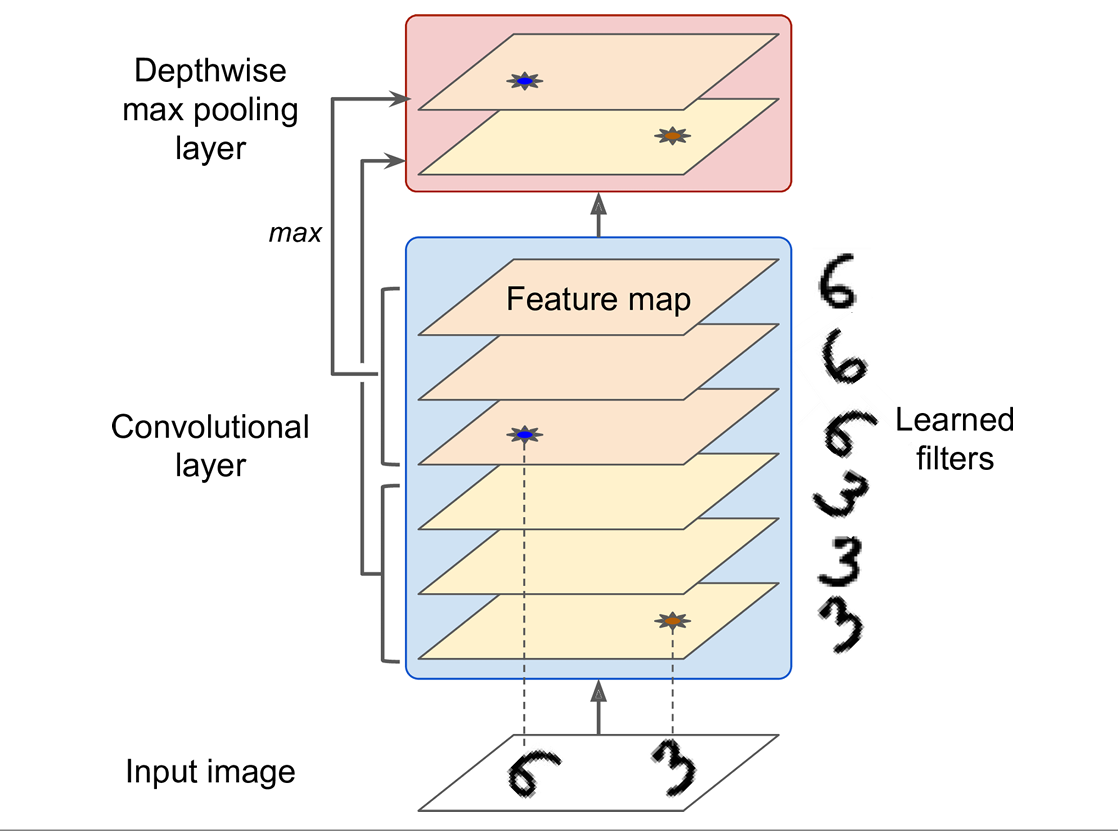

In [ ]:

#Tensorflow not includes a depthwise convolution layer, but keras does

output = tf.nn.max_pool(images,ksize=(1,2,2,1),strides=(1,2,2,1),padding="SAME")
depth_pool = keras.layers.Lambda(lambda X: tf.nn.max_pool(X,ksize=(1,2,2,1),strides=(1,2,2,1),padding="SAME"))

#usea depthwise convolution layer
outputs = keras.layers.DepthwiseConv2D(kernel_size=7,padding="same",activation="relu")(images)

#### CNN Archictetures

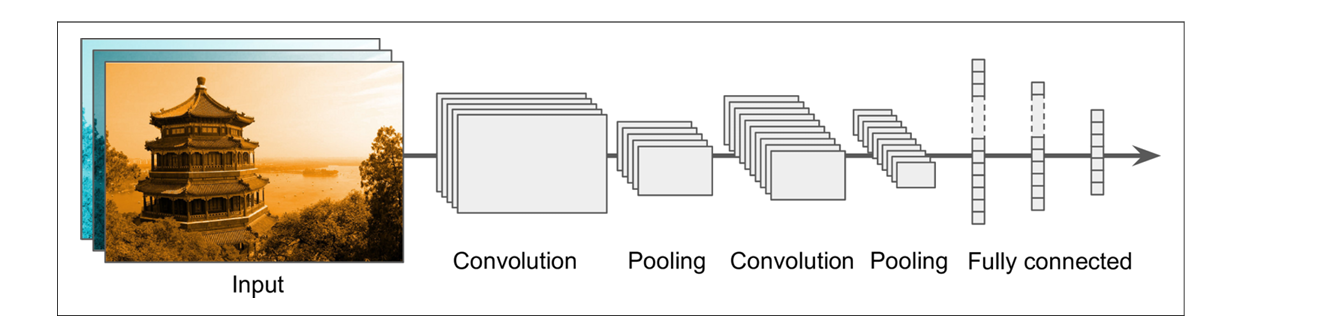

typical CNN archicteture

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Fashion-MNIST is grayscale, so add a channel dimension and normalize.
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train_full = X_train_full[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train_full: (60000, 28, 28, 1)
y_train_full: (60000,)
X_test: (10000, 28, 28, 1)
y_test: (10000,)


In [ ]:
model = keras.models.Sequential([
      keras.layers.Input(shape=[28,28,1]),
      keras.layers.Conv2D(64, 7 , activation='relu', padding='same'),
      keras.layers.MaxPooling2D(2),
      keras.layers.Conv2D(128, 3 , activation='relu', padding='same'),
      keras.layers.Conv2D(128, 3 , activation='relu', padding='same'),
      keras.layers.MaxPooling2D(2),
      keras.layers.Conv2D(256, 3 , activation='relu', padding='same'),
      keras.layers.Conv2D(256, 3 , activation='relu', padding='same'),
      keras.layers.MaxPooling2D(2),
      keras.layers.Flatten(),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dropout(0.5),
      keras.layers.Dense(64,activation ='relu'),
      keras.layers.Dropout(0.5),
      keras.layers.Dense(10,activation='softmax')    
])

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])
model.fit(X_train_full, y_train_full, epochs=10, validation_split=0.1)
model.evaluate(X_test, y_test)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.4825 - loss: 1.4126 - val_accuracy: 0.7355 - val_loss: 0.6850
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.7134 - loss: 0.7870 - val_accuracy: 0.7992 - val_loss: 0.5175
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.7744 - loss: 0.6355 - val_accuracy: 0.8283 - val_loss: 0.4587
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.7992 - loss: 0.5650 - val_accuracy: 0.8447 - val_loss: 0.4210
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.8180 - loss: 0.5215 - val_accuracy: 0.8465 - val_loss: 0.4148
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.8307 - loss: 0.4866 - val_accuracy: 0.8502 - val_loss: 0.3970
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.8414 - loss: 0.4600 - val_accuracy: 0.8658 - val_loss: 0.3713
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.8480 -

[0.379291832447052, 0.8622999787330627]

### LeNet-5

Created by Yann LeCun in 1998 - used for handwritten digit recognition 

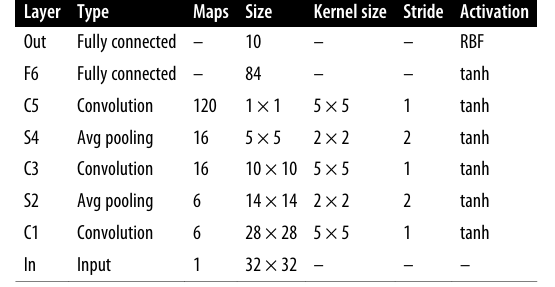

In [ ]:
# Professional ResNet-inspired architecture with BatchNormalization and Residual connections
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_residual_block(x, filters, kernel_size=3, strides=1, activation='relu', name_prefix=''):
    """Create a residual block with batch normalization"""
    shortcut = x
    
    # First conv layer
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name=f'{name_prefix}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.Activation(activation, name=f'{name_prefix}_act1')(x)
    
    # Second conv layer
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name=f'{name_prefix}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)
    
    # Adjust shortcut if necessary
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same',
                                kernel_regularizer=regularizers.l2(1e-4),
                                name=f'{name_prefix}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name_prefix}_shortcut_bn')(shortcut)
    
    # Add and activate
    x = layers.Add(name=f'{name_prefix}_add')([x, shortcut])
    x = layers.Activation(activation, name=f'{name_prefix}_act_out')(x)
    
    return x

# Build professional model
professional_model = models.Sequential([
    layers.Input(shape=[28, 28, 1]),
    
    # Initial conv block
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Residual blocks - Stage 1
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Transition - Stage 2
    layers.Conv2D(128, 3, strides=2, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    layers.Conv2D(128, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Transition - Stage 3
    layers.Conv2D(256, 3, strides=2, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    layers.Conv2D(256, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    
    # Global pooling and dense layers
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')
])

# Compile with advanced optimizer settings
professional_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

# Training with callbacks for better performance
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

print("Modelo profesional - Resumen:")
professional_model.summary()

print("\nEntrenando modelo profesional...")
history = professional_model.fit(
    X_train_full, y_train_full,
    epochs=50,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluación final
test_loss, test_accuracy = professional_model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"{'='*50}")

Modelo profesional - Resumen:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,453,578 (5.54 MB)

 Trainable params: 1,450,122 (5.53 MB)

 Non-trainable params: 3,456 (13.50 KB)


Entrenando modelo profesional...
Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 179s 206ms/step - accuracy: 0.8109 - loss: 0.6814 - val_accuracy: 0.5602 - val_loss: 2.2630 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 154s 182ms/step - accuracy: 0.8869 - loss: 0.4695 - val_accuracy: 0.8115 - val_loss: 0.7678 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 158s 187ms/step - accuracy: 0.9048 - loss: 0.4182 - val_accuracy: 0.8697 - val_loss: 0.5092 - learning_rate: 0.0010
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 161s 191ms/step - accuracy: 0.9107 - loss: 0.3943 - val_accuracy: 0.9027 - val_loss: 0.4188 - learning_rate: 0.0010
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 154s 183ms/step - accuracy: 0.9155 - loss: 0.3766 - val_accuracy: 0.8812 - val_loss: 0.4778 - learning_rate: 0.0010
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 147s 174ms/step - accuracy: 0.9178 - loss: 0.3667 - val_accuracy: 0.8845 - val_loss: 0.4670 - learning_rate: 0.0010
Epoch 7/50
844/844 ━━━━━━━━━━━

### Alex Net
Developed by Alex Krizhevsky (hence the name), Ilya Sutskever, and
Geoffrey Hinton

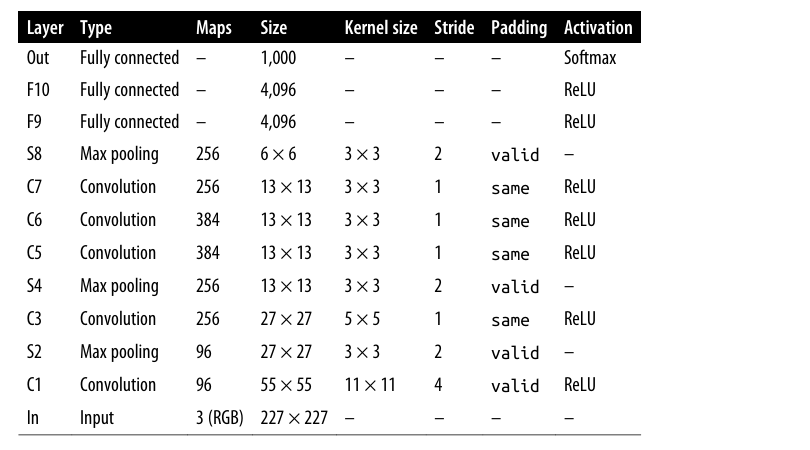

In [ ]:
# --- AlexNet-inspired architecture adapted for 28x28 grayscale images ---
from tensorflow.keras import layers, models, regularizers

# AlexNet-style model scaled for small images
def build_alexnet(input_shape=(28,28,1), n_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(96, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(256, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(384, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(384, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(256, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='AlexNet_small')
    return model

# Build, compile and show summary (training code included but commented out for optional use)
alexnet_model = build_alexnet(input_shape=(28,28,1), n_classes=10)

alexnet_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

print('\nAlexNet-adapted model summary:')
alexnet_model.summary()

# Optional training snippet (uncomment to run training):
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
# history_alex = alexnet_model.fit(X_train_full, y_train_full, epochs=30, validation_split=0.1, batch_size=64, callbacks=[early_stop, reduce_lr])
# test_loss_alex, test_acc_alex = alexnet_model.evaluate(X_test, y_test)
# print(f"AlexNet Test accuracy: {test_acc_alex:.4f}")


#### GoogleNet

Develop by Cristhian Szegedy 

-inception module
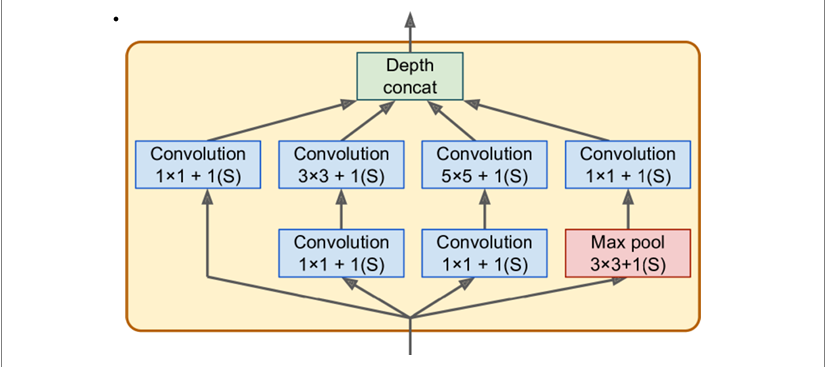


-architecture
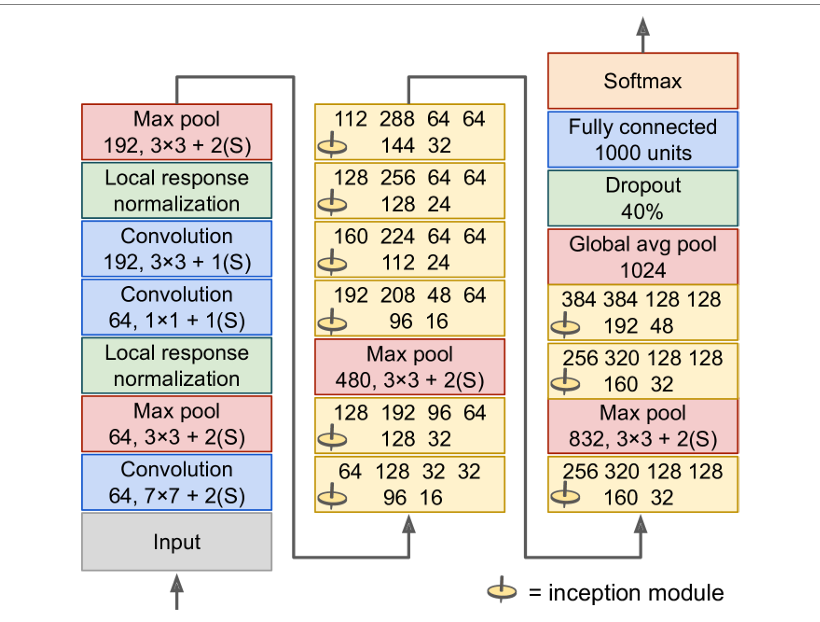


In [ ]:
# --- GoogLeNet (Inception) architecture adapted for 28x28 grayscale images ---
from tensorflow.keras import layers, models, regularizers

def inception_module(x, filters_1x1, filters_3x3_reduce, filters_3x3, 
                     filters_5x5_reduce, filters_5x5, filters_pool, name_prefix=''):
    """Inception module with 1x1, 3x3, 5x5 convolutions and max pooling"""
    
    # 1x1 conv branch
    branch_1x1 = layers.Conv2D(filters_1x1, 1, padding='same', 
                              kernel_regularizer=regularizers.l2(1e-4))(x)
    branch_1x1 = layers.BatchNormalization()(branch_1x1)
    branch_1x1 = layers.Activation('relu')(branch_1x1)
    
    # 3x3 conv branch (with 1x1 reduction first)
    branch_3x3 = layers.Conv2D(filters_3x3_reduce, 1, padding='same',
                              kernel_regularizer=regularizers.l2(1e-4))(x)
    branch_3x3 = layers.BatchNormalization()(branch_3x3)
    branch_3x3 = layers.Activation('relu')(branch_3x3)
    branch_3x3 = layers.Conv2D(filters_3x3, 3, padding='same',
                              kernel_regularizer=regularizers.l2(1e-4))(branch_3x3)
    branch_3x3 = layers.BatchNormalization()(branch_3x3)
    branch_3x3 = layers.Activation('relu')(branch_3x3)
    
    # 5x5 conv branch (with 1x1 reduction first)
    branch_5x5 = layers.Conv2D(filters_5x5_reduce, 1, padding='same',
                              kernel_regularizer=regularizers.l2(1e-4))(x)
    branch_5x5 = layers.BatchNormalization()(branch_5x5)
    branch_5x5 = layers.Activation('relu')(branch_5x5)
    branch_5x5 = layers.Conv2D(filters_5x5, 5, padding='same',
                              kernel_regularizer=regularizers.l2(1e-4))(branch_5x5)
    branch_5x5 = layers.BatchNormalization()(branch_5x5)
    branch_5x5 = layers.Activation('relu')(branch_5x5)
    
    # Max pooling branch with 1x1 projection
    branch_pool = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    branch_pool = layers.Conv2D(filters_pool, 1, padding='same',
                               kernel_regularizer=regularizers.l2(1e-4))(branch_pool)
    branch_pool = layers.BatchNormalization()(branch_pool)
    branch_pool = layers.Activation('relu')(branch_pool)
    
    # Concatenate all branches
    inception_out = layers.Concatenate()([branch_1x1, branch_3x3, branch_5x5, branch_pool])
    return inception_out

# Build GoogLeNet-style model
def build_googlenet(input_shape=(28,28,1), n_classes=10):
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolutional layers
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Inception modules
    x = inception_module(x, 64, 96, 128, 16, 32, 32, name_prefix='inception_3a')
    x = inception_module(x, 128, 128, 192, 32, 96, 64, name_prefix='inception_3b')
    x = layers.MaxPooling2D(2)(x)
    
    x = inception_module(x, 192, 96, 208, 16, 48, 64, name_prefix='inception_4a')
    x = inception_module(x, 160, 112, 224, 32, 64, 64, name_prefix='inception_4b')
    x = inception_module(x, 128, 128, 256, 32, 64, 64, name_prefix='inception_4c')
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Dense classifier
    x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.7)(x)
    
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='GoogLeNet_small')
    return model

# Build and compile GoogLeNet
googlenet_model = build_googlenet(input_shape=(28,28,1), n_classes=10)

googlenet_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

print('\nGoogLeNet-adapted model summary (Inception architecture):')
googlenet_model.summary()

# Optional training snippet (uncomment to run training):
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
# history_google = googlenet_model.fit(X_train_full, y_train_full, epochs=30, validation_split=0.1, batch_size=64, callbacks=[early_stop, reduce_lr])
# test_loss_google, test_acc_google = googlenet_model.evaluate(X_test, y_test)
# print(f"GoogLeNet Test accuracy: {test_acc_google:.4f}")


### ResNet - Residual Network 

By Kaiming He et al , composed of 152 layers  ,use shortcut connections  


-residual learning 
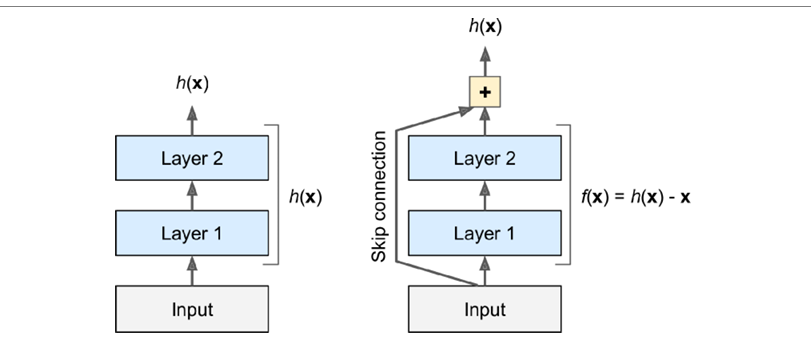

-regular deep neural network and deep residual network

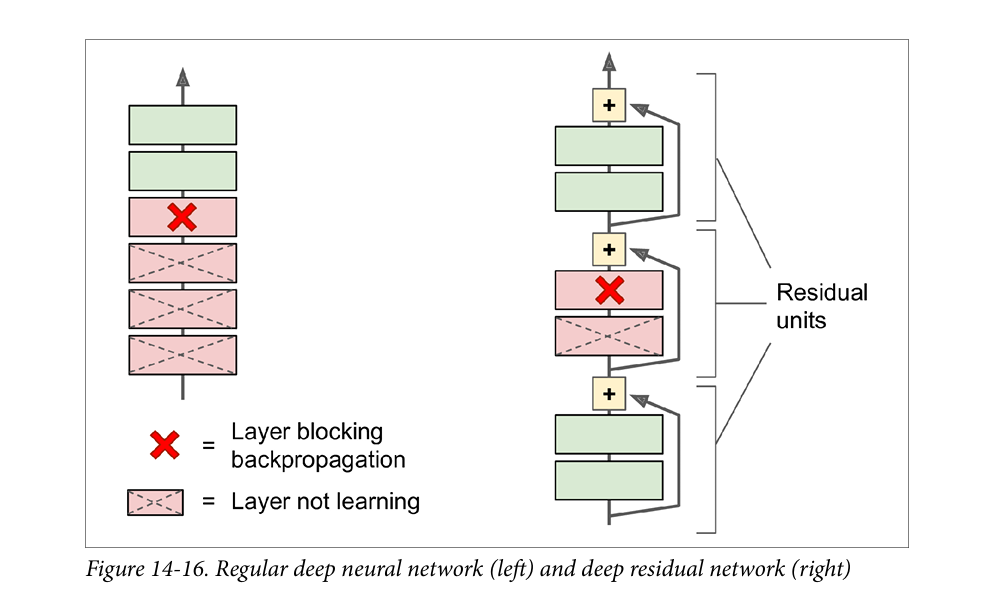

-resnet archicteture

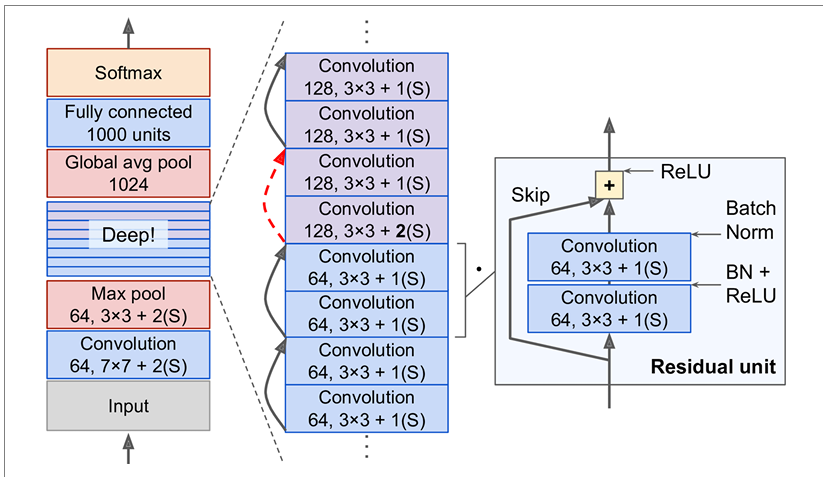

-skip connection when changing feature map size and depth 
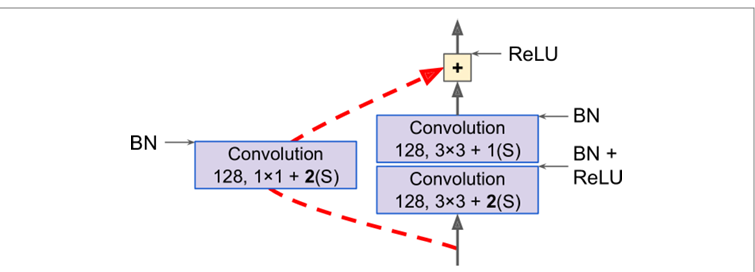

In [ ]:
# --- ResNet (Residual Networks) architecture adapted for 28x28 grayscale images ---
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, kernel_size=3, strides=1, activation='relu', name_prefix=''):
    """Residual block with skip connection"""
    shortcut = x
    
    # First conv layer
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name=f'{name_prefix}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.Activation(activation, name=f'{name_prefix}_act1')(x)
    
    # Second conv layer
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name=f'{name_prefix}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)
    
    # Adjust shortcut if necessary (different strides or channels)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same',
                                kernel_regularizer=regularizers.l2(1e-4),
                                name=f'{name_prefix}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name_prefix}_shortcut_bn')(shortcut)
    
    # Add and activate
    x = layers.Add(name=f'{name_prefix}_add')([x, shortcut])
    x = layers.Activation(activation, name=f'{name_prefix}_act_out')(x)
    
    return x

def build_resnet(input_shape=(28,28,1), n_classes=10, depth=50):
    """Build ResNet with configurable depth"""
    inputs = layers.Input(shape=input_shape)
    
    # Initial conv block
    x = layers.Conv2D(64, 7, strides=1, padding='same',
                     kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
    
    # Residual blocks - Stage 1 (64 filters)
    x = residual_block(x, 64, name_prefix='block1_1')
    x = residual_block(x, 64, name_prefix='block1_2')
    x = residual_block(x, 64, name_prefix='block1_3')
    
    # Residual blocks - Stage 2 (128 filters)
    x = residual_block(x, 128, strides=2, name_prefix='block2_1')
    x = residual_block(x, 128, name_prefix='block2_2')
    x = residual_block(x, 128, name_prefix='block2_3')
    x = residual_block(x, 128, name_prefix='block2_4')
    
    # Residual blocks - Stage 3 (256 filters)
    x = residual_block(x, 256, strides=2, name_prefix='block3_1')
    x = residual_block(x, 256, name_prefix='block3_2')
    x = residual_block(x, 256, name_prefix='block3_3')
    x = residual_block(x, 256, name_prefix='block3_4')
    x = residual_block(x, 256, name_prefix='block3_5')
    x = residual_block(x, 256, name_prefix='block3_6')
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Classification head
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='ResNet_small')
    return model

# Build and compile ResNet
resnet_model = build_resnet(input_shape=(28,28,1), n_classes=10)

resnet_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

print('\nResNet model summary (with residual connections):')
resnet_model.summary()

# Optional training snippet (uncomment to run training):
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
# history_resnet = resnet_model.fit(X_train_full, y_train_full, epochs=30, validation_split=0.1, batch_size=64, callbacks=[early_stop, reduce_lr])
# test_loss_resnet, test_acc_resnet = resnet_model.evaluate(X_test, y_test)
# print(f"ResNet Test accuracy: {test_acc_resnet:.4f}")


### Xception


-was proposed by Francois Chollet 

-replaces the inception modules with a special type or layer called a depthwise separable convolution layer

-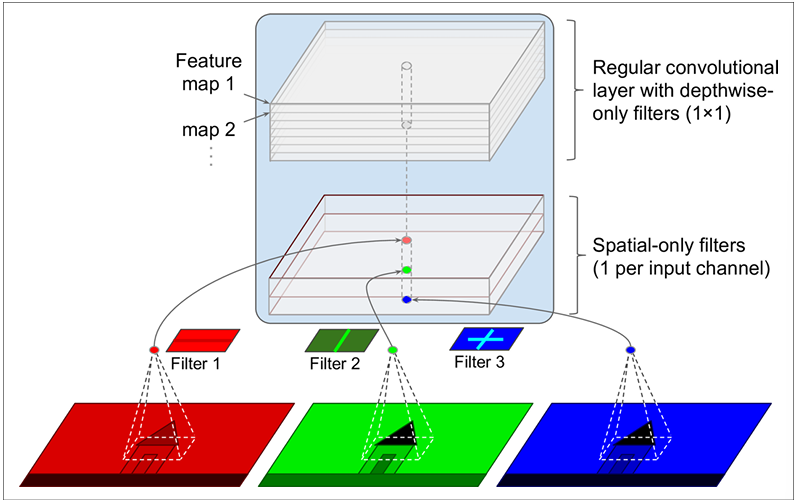

-starts with 2 regular convolutional layers


-separable convolutional layers perfom better ,so you sholud consider using them by default

### SENet 

-Adds a small neural network called an SE block
-analyuzes the output of the unit  
-learn which features are usually most active together ,this feature map recalibration will hep resolve the ambiguity

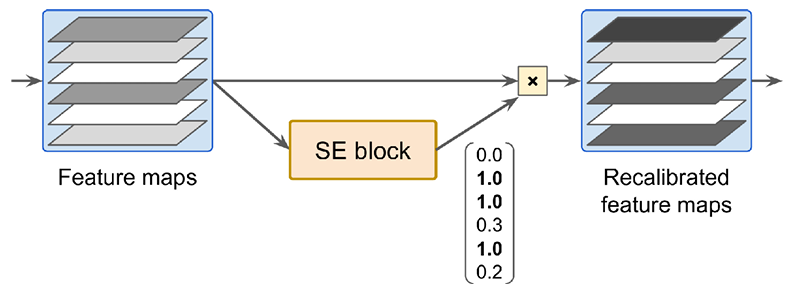

SE block is composed of just three layers 
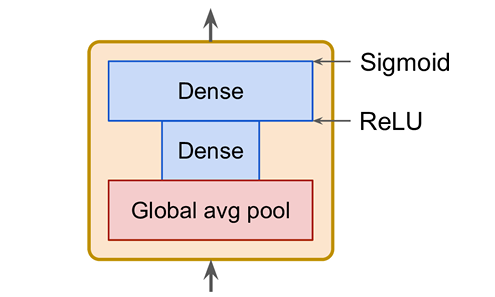

### Implementing  a ResNet-34  CNN Using Keras


In [5]:
import keras
from Layers import ResidualUnit


model = keras.models.Sequential()
model.add(keras.layers.Conv2D(64,7,strides=2,input_shape=[224,224,3],padding='same',use_bias=False ))
# model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D(pool_size=3,strides=2,padding='same'))  
prev_filters = 64
for filters in [64] * 3 + [128] * 4 +[256] * 6 +[512] * 3 :
    strides = 1 if filters  == prev_filters else 2
    model.add(ResidualUnit.ResidualUnit(filters, strides=strides))
    prev_filters = filters
model.add(keras.layers.GlobalAvgPool2D())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10,activation ='softmax'))    

### Using Pretrained Models from Keras

In [7]:
import tensorflow as tf
# you can  load the resNet-50 model pretrained 
model = keras .applications.resnet50.ResNet50(weights='imagenet', include_top=True)
#you first need to ensure that the images have the right size 
images_resized = tf.image.resize(images,[224,224])

NameError: name 'images' is not defined

The pretrained models assume that the images are preprocessed in a specific way .In some cases they may expect the inputs to be scaled from 0 to 1 ,or -1 to 1 .

-Each model provides a preprocess-input ()

-These fuctions assume that the pixel values range from 0 to 255 


In [ ]:
inputs = keras.applications.resnet50.preprocess_input(images_resized * 255)


Y_proba = model.predict(inputs)

if you want to display the top K predictions ,including the class name and the estimated probability of each predicted  class , use decode_predictions()

In [ ]:
top_k = keras.applications.resnet50.decode_predictions(Y_proba, top=3)

for image_index in range(len(images)):
    print(f"\nImage {image_index}:")
    for class_id, class_name, class_proba in top_k[image_index]:
        print("  {} - {:12s} {:.2f}%".format(class_id, class_name, class_proba * 100))
    print()

### Pretrained Models for Transfer Learning
reuse the lower layers of a pretrained model if you want to build an image classifier but do not have enough training data 

In [ ]:
import tensorflow_datasets as tfds

dataset , info  = tfds.load('tf_flowers',as_supervised = True ,with_info =True)
dataset_size = info.splits['train'].num_examples 
class_names = info.features['label'].names
n_classes =info.features['label'].num_classes

In [ ]:
#split the training set

test_split , valid_split , train_split = tfds.Split.TRAIN.subsplit([10,15,75]) 

test_set = tfds.load('tf_flowers', split=test_split, as_supervised=True)
valid_set = tfds.load('tf_flowers', split=valid_split, as_supervised=True)
train_set = tfds.load('tf_flowers', split=train_split, as_supervised=True)

In [ ]:
# Process the images  ,the CNN expects 224 * 224  images ,we nees to resize them 
def preprocess(image,label):
    resized_image = tf.image.resize(image,[224,224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image , label

#Apply the preprocessing to the datasets
batch_size = 32
train_set = train_set.shuffle(1000)
train_set = train_set.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_set = valid_set.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_set = test_set.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [ ]:
#Exclude the top of the network by setting  include_top=False when loading the pretrained model, and add a new classification head on top of it.
#this exclude the global average pooling layer and the dense output layer .

base_model = keras.applications.xception.Xception(weights='imagenet', include_top=False )
avg = keras.layers.GlobalAvgPooling2D()(base_model.output)
output = keras.layers.Dense(n_classes,activation='softmax')(avg)
model = keras.Model(inputs=base_model.input  , outputs =output)


# is a good idea to freese the weights of the pretrained layers 

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
#Finally , we can compile the model and start training

optimizer = keras.optimizers.SGD(lr=0.2 , momentum=0.9 , decay=0.01)
model.compile(loss='sparse_categorical_crossentropy',optimizer=optimizer
              ,metrics=['accuracy'])
history = model.fit(train_set, epochs=10, validation_data=valid_set)

In [ ]:
#This means that the top layers are now pretty well trained 
#so we are ready to unfreeze all the layers 
for layer in model.layers:
    layer.trainable = True  
optimizer = keras.optimizers.SGD(lr=0.01 , momentum=0.9 , decay=0.001)
model.compile(loss='sparse_categorical_crossentropy',optimizer=optimizer    ,metrics=['accuracy'])
history_fine = model.fit(train_set, epochs=10, validation_data=valid_set)

### Classification and Localization

In [ ]:
base_model = keras.applications.xception.Xception(weights='imagenet',   include_top=False)
avg = keras.layers.GlobalAvgPooling2D()(base_model.output)
class_output = keras.layers.Dense(n_classes,activation='softmax')(avg)
loc_output = keras.layers.Dense(4)(avg)
model = keras.Model(inputs=base_model.input, outputs=[class_output, loc_output])
model.compile(loss=['sparse_categorical_crossentropy', 'mse'],loss_weights=[0.8,0.2] ,optimizer=optimizer, metrics=['accuracy'])


###  Fully Convolutional Network
-Introduced  by jonathan Long et at . for semantic segmetation ,the autor  pointed out that you could replace the dense layers at the top of a CNN by convolutional layers .

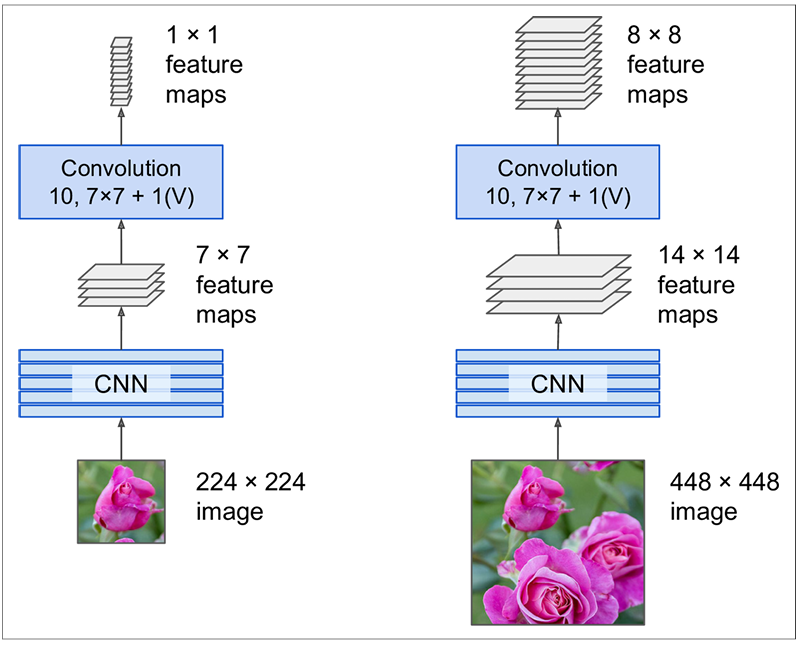

### Yolo  -You only look once

proposed  by Joseph Redmon et al ,subsequently improved (YOLOv2) and (YOLOv3) this archicteture is quite similar to the one we just discussed but with a few important differences

-YOLO V3 applies the logistic activation fuction 
- finds five representative bounding box ,called anchor boxes 
-YOLO9000 predicts a probability for each node in a visual hierachy called WordTree


In [9]:
from dataclasses import dataclass
from pathlib import Path
import random
import subprocess
import sys
import numpy as np

try:
    from ultralytics import YOLO
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO

try:
    import torch
except ImportError:
    torch = None

# YOLOv8 end-to-end example (training + validation + inference + export)
# Demo dataset: coco8 (small, fast, suitable for notebook examples)

@dataclass
class YOLOConfig:
    weights: str = "yolov8n.pt"
    data: str = "coco8.yaml"
    epochs: int = 15
    imgsz: int = 640
    batch: int = 16
    project: str = "runs/yolov8"
    name: str = "coco8_demo"
    conf: float = 0.25


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


def get_device() -> int | str:
    if torch is not None and torch.cuda.is_available():
        return 0
    return "cpu"


def run_yolov8_pipeline(cfg: YOLOConfig):
    set_seed(42)
    device = get_device()

    yolo_model = YOLO(cfg.weights)

    # 1) Train
    train_results = yolo_model.train(
        data=cfg.data,
        epochs=cfg.epochs,
        imgsz=cfg.imgsz,
        batch=cfg.batch,
        device=device,
        project=cfg.project,
        name=cfg.name,
        pretrained=True,
        optimizer="auto",
        verbose=True,
    )

    # 2) Validate
    val_metrics = yolo_model.val(data=cfg.data, imgsz=cfg.imgsz, device=device)
    print(f"mAP50-95: {val_metrics.box.map:.4f}")
    print(f"mAP50:    {val_metrics.box.map50:.4f}")

    # 3) Predict (example image)
    yolo_model.predict(
        source="https://ultralytics.com/images/bus.jpg",
        conf=cfg.conf,
        imgsz=cfg.imgsz,
        device=device,
        save=True,
    )

    # 4) Export best model to ONNX
    best_weights = Path(train_results.save_dir) / "weights" / "best.pt"
    best_model = YOLO(str(best_weights))
    export_path = best_model.export(format="onnx", dynamic=True, simplify=True)
    print(f"Exported ONNX model: {export_path}")

    return yolo_model, train_results, val_metrics


cfg = YOLOConfig()
yolo_model, train_results, val_metrics = run_yolov8_pipeline(cfg)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\User\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46  Python-3.13.13 torch-2.11.0+cpu CPU (AMD Ryzen 7 7435HS)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

#### Super Resolution
Skip layers recover some spatial resolution from lower layers

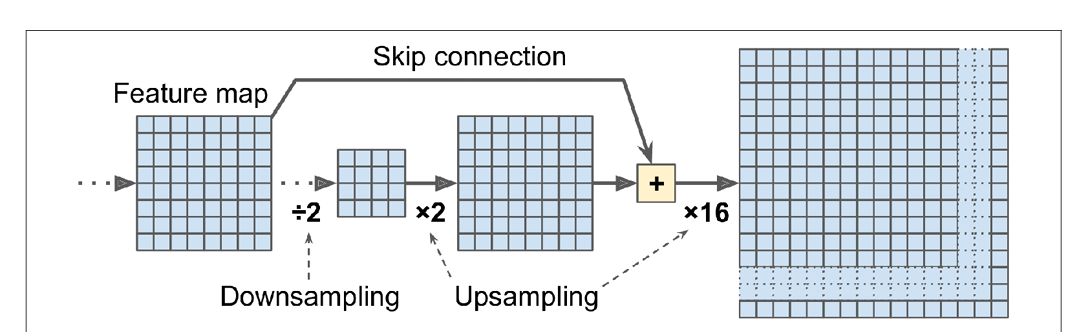

In [ ]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

# Super Resolution using YOLOv8 backbone features

def build_super_resolution_model(upscale_factor=4, input_shape=(64, 64, 3)):
    """
    Build a super resolution model using skip connections similar to YOLO architecture.
    Upscales low-resolution images by the specified factor.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Feature extraction blocks with skip connections
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.Activation('relu')(x)
    skip1 = x
    
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Activation('relu')(x)
    x = layers.Add()([x, skip1])
    
    skip2 = x
    x = layers.Conv2D(32, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Activation('relu')(x)
    
    # Upsample blocks (similar to YOLO decoder)
    for _ in range(int(np.log2(upscale_factor))):
        x = layers.UpSampling2D(size=2, interpolation='nearest')(x)
        x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.Activation('relu')(x)
    
    # Reconstruction
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.Activation('relu')(x)
    outputs = layers.Conv2D(3, 3, padding='same', activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs, name='SuperResolution')
    return model

# Build and compile the super resolution model
sr_model = build_super_resolution_model(upscale_factor=4, input_shape=(64, 64, 3))
sr_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

print('Super Resolution Model Summary:')
sr_model.summary()